In [1]:
import duckdb as db
import pandas as pd
import numpy as np

In [2]:
PATH = "clean_flights.parquet"

In [3]:
con = db.connect()

In [5]:
total_rows = con.execute(
    f"""
    SELECT COUNT(*)
    FROM read_parquet('{PATH}')
    """
).fetchone()[0]

print(f"Totoal flights: {total_rows}")

Totoal flights: 36367047


## Initial Weather EDA

In [20]:
weather_stats = con.execute(
    f""" 
    SELECT
        COUNT(*) AS total_flights,
        SUM(CASE WHEN WeatherDelay > 0 THEN 1 ELSE 0 END) AS weather_flights,
        AVG(CASE WHEN WeatherDelay > 0 THEN 1 ELSE 0 END) AS weather_probability,
        AVG(WeatherDelay) AS avg_weather_minutes
    FROM read_parquet('{PATH}')
    """).df()

weather_stats

,total_flights,weather_flights,weather_probability,avg_weather_minutes
0,36367047,415640.0,0.011429,4.181365


Weather-related delays occur in only about 1% of flights, indicating that weather is a relatively rare but potentially impactful disruption factor.

In [23]:
avg_weather_delay_min = con.execute(f"""
    SELECT AVG(WeatherDelay)
    FROM read_parquet('{PATH}')
    WHERE WeatherDelay > 0
""").fetchone()[0]

med_weather_delay_min = con.execute(f"""
    SELECT MEDIAN(WeatherDelay)
    FROM read_parquet('{PATH}')
    WHERE WeatherDelay > 0
""").fetchone()[0]

print(avg_weather_delay_min, med_weather_delay_min)

69.69598209989414 34.0


In [13]:
df = con.execute(f"""
    SELECT 
        WeatherDelay
    FROM read_parquet('{PATH}')
    USING SAMPLE 100000 ROWS""").df()

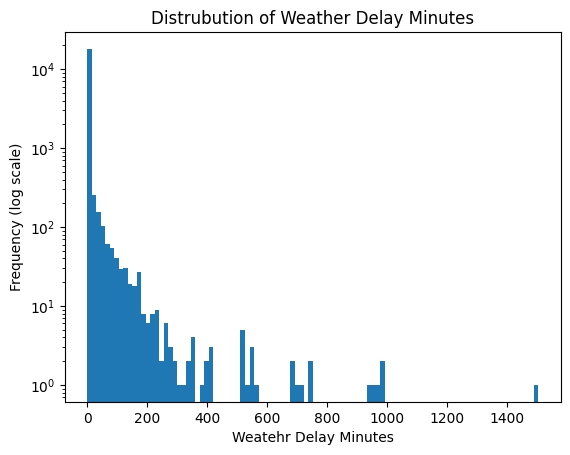

In [14]:
import matplotlib.pyplot as plt

plt.hist(df["WeatherDelay"], bins = 100, log = True)
plt.title("Distrubution of Weather Delay Minutes")
plt.xlabel("Weatehr Delay Minutes")
plt.ylabel("Frequency (log scale)")
plt.show()

In [15]:
monthly_weather = con.execute(f"""
    SELECT
        Month,
        AVG(WeatherDelay) AS avg_weather_delay,
        AVG(CASE WHEN WeatherDelay > 0 THEN 1 ELSE 0 END) AS weather_frequency
    FROM read_parquet('{PATH}')
    GROUP BY Month
    ORDER BY Month
""").df()

monthly_weather

,Month,avg_weather_delay,weather_frequency
0,1,5.702424,0.013094
1,2,4.784609,0.011156
2,3,3.210389,0.008405
3,4,3.562366,0.009616
4,5,4.506900,0.013285
5,6,4.587866,0.017102
6,7,4.662801,0.018412
7,8,4.772337,0.014812
8,9,3.397271,0.008027
9,10,2.450664,0.005449


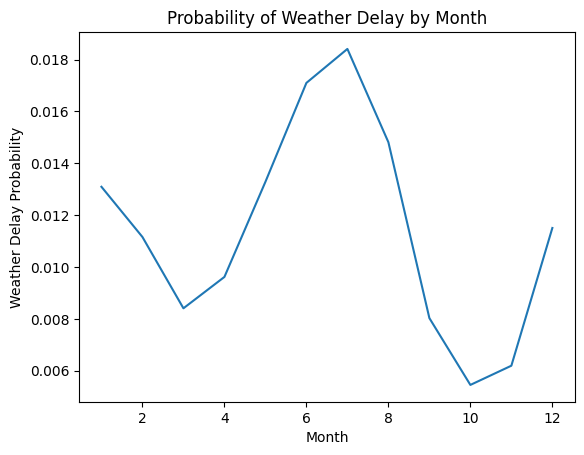

In [16]:
plt.plot(monthly_weather["Month"], monthly_weather["weather_frequency"])
plt.title("Probability of Weather Delay by Month")
plt.xlabel("Month")
plt.ylabel("Weather Delay Probability")
plt.show()

## Analyze Weather Delay by Severity

In [30]:
severity_weather = con.execute(f"""
SELECT
    CASE
        WHEN GREATEST(DepDelayMinutes, ArrDelayMinutes) <= 15 THEN 'OnTime (<= 15 min delay)'
        WHEN GREATEST(DepDelayMinutes, ArrDelayMinutes) <= 60 THEN 'Mild (<= 60 min delay)'
        WHEN GREATEST(DepDelayMinutes, ArrDelayMinutes) <= 180 THEN 'Moderate (<= 180 min delay)'
        ELSE 'Severe (> 180 min delay)'
    END AS DelayCategory,
    COUNT(*) AS total_flights,
    COUNT(*) * 1.0 / SUM(COUNT(*)) OVER() AS pct_of_total,
    AVG(WeatherDelay) AS avg_weather,
    AVG(CarrierDelay) AS avg_carrier,
    AVG(NASDelay) AS avg_nas,
    AVG(LateAircraftDelay) AS avg_late_aircraft
FROM read_parquet('{PATH}')
GROUP BY DelayCategory
ORDER BY total_flights DESC
""").df()

severity_weather

,DelayCategory,total_flights,pct_of_total,avg_weather,avg_carrier,avg_nas,avg_late_aircraft
0,OnTime (<= 15 min delay),28344047,0.779388,0.154459,3.623655,9.911550,1.274272
1,Mild (<= 60 min delay),5415578,0.148914,0.900536,10.158056,9.417340,9.367737
2,Moderate (<= 180 min delay),2130170,0.058574,5.220746,30.331335,16.216207,40.151921
3,Severe (> 180 min delay),477252,0.013123,29.463385,141.927775,31.619267,120.633526


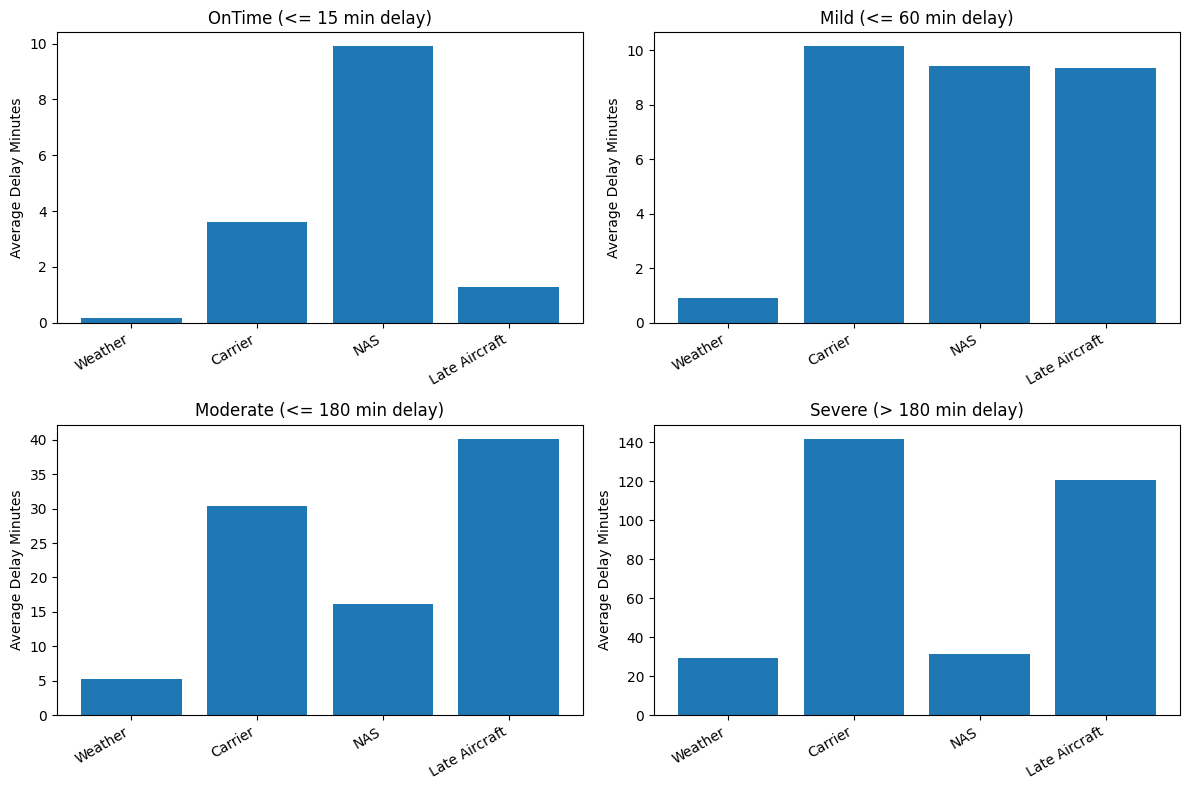

In [33]:
categories = [
    "OnTime (<= 15 min delay)",
    "Mild (<= 60 min delay)",
    "Moderate (<= 180 min delay)",
    "Severe (> 180 min delay)"
]

cause_cols = ["avg_weather", "avg_carrier", "avg_nas", "avg_late_aircraft"]
cause_labels = ["Weather", "Carrier", "NAS", "Late Aircraft"]

plt.figure(figsize=(12, 8))

for i, cat in enumerate(categories, 1):
    row = severity_weather[severity_weather["DelayCategory"] == cat].iloc[0]
    values = [row[c] for c in cause_cols]

    plt.subplot(2, 2, i)
    plt.bar(cause_labels, values)
    plt.title(cat)
    plt.ylabel("Average Delay Minutes")
    plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

Question: For each delay type, the average, weather, carrier, NAS, and Late aircraft are all much lower than the defined type of delay. Is is possible that each flight delay is a comination of types of delays?

In [36]:
check_all = con.execute(f"""
SELECT
    CASE
        WHEN GREATEST(DepDelayMinutes, ArrDelayMinutes) <= 15 THEN 'OnTime'
        WHEN GREATEST(DepDelayMinutes, ArrDelayMinutes) <= 60 THEN 'Mild'
        WHEN GREATEST(DepDelayMinutes, ArrDelayMinutes) <= 180 THEN 'Moderate'
        ELSE 'Severe'
    END AS DelayCategory,

    AVG(GREATEST(DepDelayMinutes, ArrDelayMinutes)) AS avg_total_delay,

    AVG(
        COALESCE(CarrierDelay, 0) +
        COALESCE(WeatherDelay, 0) +
        COALESCE(NASDelay, 0) +
        COALESCE(LateAircraftDelay, 0) +
        COALESCE(SecurityDelay, 0)
    ) AS avg_sum_components

FROM read_parquet('{PATH}')
GROUP BY DelayCategory
ORDER BY DelayCategory;
""").df()

check_all

,DelayCategory,avg_total_delay,avg_sum_components
0,Mild,31.473479,23.139704
1,Moderate,99.742374,92.081188
2,OnTime,1.838893,0.072372
3,Severe,332.507195,323.929415


## Weather Analysis by Airport

### Weather Frequency by Airport

In [42]:
airport_weather_conditional = con.execute(f"""
SELECT
    Origin,
    COUNT(*) AS total_flights,
    AVG(CASE WHEN WeatherDelay > 0 THEN 1 ELSE 0 END) AS weather_frequency,
    AVG(CASE WHEN WeatherDelay > 0 THEN WeatherDelay END) AS avg_weather_when_occurs
FROM read_parquet('{PATH}')
GROUP BY Origin
HAVING COUNT(*) > 10000
ORDER BY avg_weather_when_occurs DESC
LIMIT 30;
""").df()

airport_weather_conditional

,Origin,total_flights,weather_frequency,avg_weather_when_occurs
0,SUN,10839,0.024080,141.980843
1,GTF,14313,0.015510,124.729730
2,MRY,23105,0.011123,121.439689
3,FLG,10711,0.016245,120.568966
4,RDM,36709,0.015773,116.412781
5,SAF,12617,0.029643,116.056150
6,PSC,30858,0.014939,112.683297
7,MOT,13940,0.031349,111.631579
8,IDA,20836,0.020301,110.316785
9,MFR,32590,0.013164,108.247086


### Plot Map of Airports and Weather Delay Severity

In [43]:
airports = pd.read_csv("airports.csv")

airports = airports.rename(columns={
    "IATA": "airport",
    "LATITUDE": "lat",
    "LONGITUDE": "lon"
})

airports = airports[["airport", "lat", "lon"]]

airports.head()

,airport,lat,lon
0,ABQ,35.040222,-106.609194
1,ANC,61.174320,-149.996186
2,ATL,33.640444,-84.426944
3,AUS,30.194533,-97.669872
4,BDL,41.938874,-72.683228


In [44]:
merged = airport_weather_conditional.merge(
    airports,
    left_on="Origin",
    right_on="airport",
    how="inner"
)

merged.head()

,Origin,total_flights,weather_frequency,avg_weather_when_occurs,airport,lat,lon
0,SUN,10839,0.024080,141.980843,SUN,43.504841,-114.296590
1,GTF,14313,0.015510,124.729730,GTF,47.482002,-111.370685
2,MRY,23105,0.011123,121.439689,MRY,36.586982,-121.842948
3,FLG,10711,0.016245,120.568966,FLG,35.138455,-111.671218
4,RDM,36709,0.015773,116.412781,RDM,44.254067,-121.149963


In [48]:
import plotly.express as px
import plotly.io as pio

fig = px.scatter_geo(
    merged,
    lat="lat",
    lon="lon",
    scope="usa",
    hover_name="Origin",
    size="weather_frequency",                 # bubble size = frequency
    color="avg_weather_when_occurs",          # color = severity
    projection="albers usa",
    title="US Airports: Weather Delay Hotspots (2020–2025)",
    color_continuous_scale="Reds"
)

fig.update_layout(height=1000)
pio.renderers.default = "browser"
fig.show()

### Animation of U.S. Map by Month

In [55]:
MIN_TOTAL_FLIGHTS = 10000

airport_weather_ym = con.execute(f"""
WITH big_airports AS (
  SELECT Origin AS airport
  FROM read_parquet('{PATH}')
  GROUP BY Origin
  HAVING COUNT(*) > {MIN_TOTAL_FLIGHTS}
)

SELECT
    Origin AS airport,
    strftime(FlightDate, '%Y-%m') AS ym,
    COUNT(*) AS total_flights,
    AVG(CASE WHEN WeatherDelay > 0 THEN 1 ELSE 0 END) AS weather_frequency,
    AVG(CASE WHEN WeatherDelay > 0 THEN WeatherDelay END) AS avg_weather_when_occurs
FROM read_parquet('{PATH}')
WHERE Origin IN (SELECT airport FROM big_airports)
GROUP BY airport, ym
ORDER BY ym, airport
""").df()

In [56]:
airports = pd.read_csv("airports.csv").rename(columns={
    "IATA": "airport",
    "LATITUDE": "lat",
    "LONGITUDE": "lon"
})[["airport", "lat", "lon", "STATE"]]

merged_ym = airport_weather_ym.merge(airports, on="airport", how="inner")

In [57]:
fig = px.scatter_geo(
    merged_ym,
    lat="lat",
    lon="lon",
    scope="usa",
    hover_name="airport",
    hover_data={
        "STATE": True,
        "ym": True,
        "total_flights": True,
        "weather_frequency": ':.3%',
        "avg_weather_when_occurs": ':.1f',
        "lat": False,
        "lon": False
    },
    size="weather_frequency",                 # bubble size = frequency
    color="avg_weather_when_occurs",          # color = severity (conditional)
    animation_frame="ym",
    projection="albers usa",
    title="US Airports: Weather Delay Hotspots Over Time (2020–2025)"
)

# Keep the color scale consistent across frames
fig.update_coloraxes(
    cmin=merged_ym["avg_weather_when_occurs"].quantile(0.05),
    cmax=merged_ym["avg_weather_when_occurs"].quantile(0.95)
)

fig.update_layout(height=650)
fig.show(renderer="browser")